# Supervised Learning - Regression
## Agenda
- Regression
- Types of Regression
  - Linear Regression
    - Simple Linear Regression
        - Train Test Split
    - Multiple Linear Regression
        - Overfitting and Underfitting
  - Non Linear Regression
     - Polynomial Regression
- Model Evaluation and Validation
  - Cross Validation Techniques
  - Performanace Metrics
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - Mean Absolute Error(MAE)
    - R-Squared (r2 Score)
- Regularization Techniques
  - Lasso Regression
  - Ridge Regression
- Hyperparameter Tuning
  - GridSearchCV
  - RandomSearchCV
- Pipelining in scikit-learn
  

## Regression

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

## Applications of Regression

1. Oil and Gas Industry: Various types of data are collected in the oil and gas industry from the surface and subsurface to understand production and sale processes. Linear and non-linear regression models forecast global oil production.
2. Marketing: In marketing, linear regression helps analyze the effectiveness of advertising campaigns, predict sales based on marketing spend, and segment customers based on demographic data.
3. Retail: Linear regression is utilized in retail for demand forecasting, inventory management, pricing optimization, and customer analytics.
4. Healthcare: Linear regression is applied in healthcare for predicting patient outcomes, analyzing the relationship between medical variables and disease progression, and planning healthcare resources.
5. Real Estate: In the real estate industry, linear regression predicts property prices based on factors such as location, size, amenities, and economic indicators.


## Types Of Regression

Regression types can be classified into two categories: linear and non-linear.

**Linear Regression**

Definition: Linear regression finds a straight-line relationship between the dependent variable and one or more independent variables.

**Non-Linear Regression**

Definition: Non-linear regression finds a relationship between the dependent variable and independent variables using a curve or a more complex shape.


## Linear Regression


**Linear Regression** refers to a supervised learning algorithm used to predict a continuous target variable by modeling its relationship with one or more independent variables through a linear equation.
- It predicts a continuous dependent variable based on one or more independent variables.
- It uses the least squares criterion to estimate the coefficients of the regression equation..
- It can be applied only if there is a linear relationship between the variables.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

In this case, the dependent variable is continuous, and the independent variables can be either continuous or discrete.


The relationship between a dependent variable (y) and one or more independent variables (x) is established using a best-fit straight line, also known as the regression line.

There are two types of linear regression:
- Simple linear regression
- Multiple linear regression

### __Simple Linear Regression__ 
**Simple Linear Regression**

Definition: Simple linear regression models the relationship between one independent variable and the dependent variable as a straight line.
The equation for Simple Linear Regression is:
 $$ \hat{y} = \beta_0 + \beta_1x $$
where:
- $\hat{y}$ is the dependent variable
- $x$ is the independent variable
- $β_0$ is the intercept
- $β_1$ is the slope


### __Multiple Linear Regression__ ###
**Multiple Linear Regression**
Definition: Multiple linear regression models the relationship between two or more independent variables/predictors/features and the dependent variable as a straight line.
The equation for Multiple Linear Regression:
 $$ \hat{y_i} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \beta_px_ p $$
 or
 $$ \hat{y_i} = \beta_0 + \sum_{j=1}^{p} \beta_j.x_{ij} $$
- $ x_1, x_2, \ldots, x_n $ are the predictor variables,
- $ \beta_1, \beta_2, \ldots, \beta_p $ are the coefficients for each predictor.

In [1]:
## Let us see how to fit the linear Regresscion model on a dataset

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Read the dataset
df =  pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [4]:
## General Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [5]:
## Statistical Summary
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [6]:
## Missing Value Check

df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [7]:
## Seperate Features as DataFrame and Target as Series

X =  df.iloc[:, :-1]  ## Extracted Features
y =  df.iloc[:, -1]  ## Extracted Target(which is the Last Column

### Perform Train Test Split

Train-test split is a technique in machine learning used to evaluate a model's performance by dividing the data into two parts: a training set and a test set. The model is trained on the training set, learning patterns and parameters, and then evaluated on the test set to see how well it generalizes to new, unseen data.

**Note:** This train-test data split will be used for other implementations as well.

In [8]:
## Install scikit-learn

#!pip install scikit-learn

In [9]:
# Import train_test_split from sklearn model_selection module
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size =  0.2, random_state = 42) 

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(160, 1)
(40, 1)
(160,)
(40,)


In [12]:
## Let us try to see if linear regression works on this data
## Import LinearRegression class from sklearn.linear_model module
## Instantiate the class
### Train the model

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [14]:
## Train the model

lin_reg.fit(X_train, y_train)

LinearRegression()

In [15]:
## Display Coefficient of Regression and Intercept Values

print(f'Coefficient of Regression  is {lin_reg.coef_}')
print(f'Intercept is {lin_reg.intercept_}')

Coefficient of Regression  is [0.04652973]
Intercept is 7.1196384305929525


The Equation of prediction line can be written as `Sales_predicted = 0.0464078 * TV + 7.23945983075114`

In [16]:
## Lets find out model prediction on train data and test data

y_train_pred =  lin_reg.predict(X_train)
y_test_pred =  lin_reg.predict(X_test)

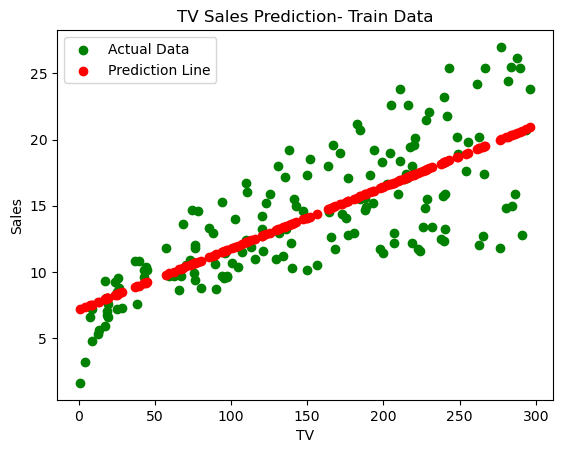

In [17]:
## Visuaize the results

plt.scatter(X_train, y_train, color = 'green', label = 'Actual Data')
plt.scatter(X_train, y_train_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Train Data')
plt.show()

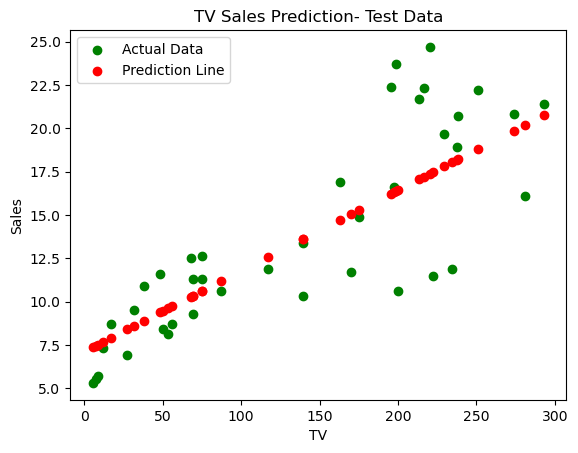

In [18]:
## Visuaize the results

plt.scatter(X_test, y_test, color = 'green', label = 'Actual Data')
plt.scatter(X_test, y_test_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Test Data')
plt.show()

# __Date: 21-08-2025__

## Overfitting and UnderFitting 
When developing machine learning models, achieving the right balance between complexity and simplicity is crucial. This balance is covered in the concepts of overfitting and underfitting.

**Overfitting**
- Overfitting occurs when a model learns the noise and details in the training data too well to the extent that it negatively impacts its performance on new unseen data.
- Sign: High accuracy on training data but poor accuracy on test data.
- Cause: Model is too complex (too many parameters).

**Underfitting**
- Underfitting happens when a model is too simple to capture the underlying pattern of the data.
- Sign: Poor accuracy on both training and test data.
- Cause: Model is too simple (too few parameters).


  
**Bias-Variance Tradeoff**
- Bias: Error due to overly simplistic assumptions in the learning algorithm. High bias can cause underfitting.
- Variance: Error due to excessive complexity in the learning algorithm. High variance can cause overfitting.
**Tradeoff**
- Low Bias & High Variance: Model fits the training data very well but may fail to generalize (overfitting).
- High Bias & Low Variance: Model does not fit the training data well and misses the underlying trend (underfitting).
- Optimal Tradeoff: Finding a balance where the model performs well on both training and test data, minimizing overall error.
 
Understanding and managing the bias-variance tradeoff is key to building models that generalize well to unseen data.

In [19]:
## Let us calculate the errors made by the previous on train data and test data

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
mse_train =  mean_squared_error(y_train, y_train_pred)
mse_test=  mean_squared_error(y_test, y_test_pred)

print(f'Mean Sq. Error Train :  {mse_train:.4f}')
print(f'Mean Sq. Error Test :  {mse_test:.4f}')

Mean Sq. Error Train :  10.6036
Mean Sq. Error Test :  10.2047


In [22]:
r2_train =  r2_score(y_train, y_train_pred)
r2_test=  r2_score(y_test, y_test_pred)

print(f'R2 Score Train :  {r2_train:.4f}')
print(f'R2 Score  Test :  {r2_test:.4f}')

R2 Score Train :  0.5912
R2 Score  Test :  0.6767


In [23]:
# Check for overfitting or underfitting
if mse_train < mse_test or r2_train > r2_test:
    if abs(r2_train - r2_test) > 0.1:
        print("Model may be overfitting to the training data.")
    else:
        print("Model performs reasonably well but check for slight overfitting.")
elif mse_train > mse_test and r2_train < r2_test:
    print("Model may be underfitting, consider increasing model complexity.")
else:
    print("Model has a balanced fit on both training and testing datasets.")

Model may be underfitting, consider increasing model complexity.


**Observation**

 Mean Squared Error (MSE) and R-squared (R²) values are calculated for both training and test datasets.
 - MSE measures the average of the squares of the errors, that is, the average squared difference between the estimated values and the actual value.
 - R² provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model

Overfitting: The model performs well on the training data but poorly on the test data (higher R² on training or lower MSE on training compared to testing).

Underfitting: The model performs poorly on both training and test data, or better on the test data compared to the training data, which could suggest that the model is too simple.
We'll discuss more about MSE, R² and various other performance metrices, further in the lesson

## Non Linear Regression

**Polynomial Regression** is a subset of linear regression that includes polynomial terms.
The relationship between an independent variable (x) and a dependent variable (y) is modeled as an nth-degree polynomial.

- Polynomial regression is also called as the special case of multiple linear regression. Some polynomial terms are added to the multiple linear regression equation to convert into polynomial regression.
- It is a linear model with some modifications made to increase its accuracy.
- The dataset used in polynomial regression for training is non-linear

- it is seen that the straight line is unable to capture the patterns in the given data.
- To achieve a higher-order equation that captures complex data patterns, the powers of the original features can be added as new features.


- It provides the best approximation of the relationship between a dependent and an independent variable.
- It captures most data points and decreases the error between the actual and the predicted values.

# __Date: 22-08-2025__

In [24]:
## Let us implement Non Linear Regression using polynomial terms

In [25]:
## using the train test split data from previous example
X_train.head()

,TV
79,116.0
197,177.0
38,43.1
24,62.3
122,224.0


In [26]:
# Let us create polynomial feature upto required degree for X_train and X_test

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [28]:
poly_features =  PolynomialFeatures(degree = 5, include_bias = False)

X_train_poly =  poly_features.fit_transform(X_train)
X_test_poly =  poly_features.transform(X_test)

In [29]:
X_train.head(2)

,TV
79,116.0
197,177.0


In [30]:
X_train_poly[:2, :]

array([[1.16000000e+02, 1.34560000e+04, 1.56089600e+06, 1.81063936e+08,
        2.10034166e+10],
       [1.77000000e+02, 3.13290000e+04, 5.54523300e+06, 9.81506241e+08,
        1.73726605e+11]])

In [31]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [32]:
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

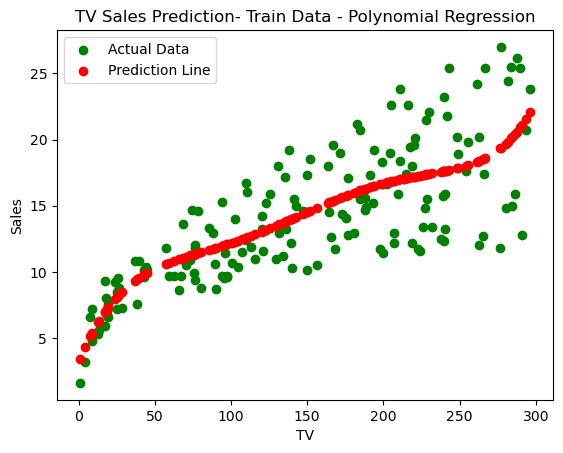

In [33]:
## Visualize the results

plt.scatter(X_train, y_train, color = 'green', label = 'Actual Data')
plt.scatter(X_train, y_train_pred_poly, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Train Data - Polynomial Regression')
plt.show()

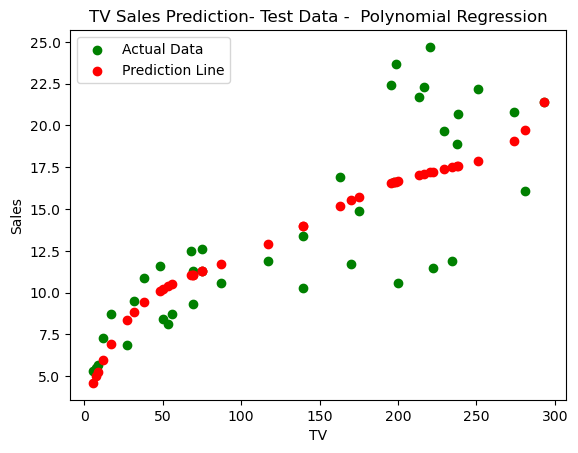

In [34]:
## Visualize the results

plt.scatter(X_test, y_test, color = 'green', label = 'Actual Data')
plt.scatter(X_test, y_test_pred_poly, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Test Data -  Polynomial Regression')
plt.show()

In [35]:
mse_train =  mean_squared_error(y_train, y_train_pred_poly)
mse_test=  mean_squared_error(y_test, y_test_pred_poly)

print(f'Mean Sq. Error Train :  {mse_train:.4f}')
print(f'Mean Sq. Error Test :  {mse_test:.4f}')

r2_train =  r2_score(y_train, y_train_pred_poly)
r2_test=  r2_score(y_test, y_test_pred_poly)

print(f'R2 Score Train :  {r2_train:.4f}')
print(f'R2 Score  Test :  {r2_test:.4f}')


Mean Sq. Error Train :  10.0658
Mean Sq. Error Test :  10.2051
R2 Score Train :  0.6119
R2 Score  Test :  0.6767


In [36]:
# Check for overfitting or underfitting
if mse_train < mse_test or r2_train > r2_test:
    if abs(r2_train - r2_test) > 0.1:
        print("Model may be overfitting to the training data.")
    else:
        print("Model performs reasonably well but check for slight overfitting.")
elif mse_train > mse_test and r2_train < r2_test:
    print("Model may be underfitting, consider increasing model complexity.")
else:
    print("Model has a balanced fit on both training and testing datasets.")

Model performs reasonably well but check for slight overfitting.


# Model Evaluation and Validation

## Performance Metrics

In Regression, Evaluation metrics gives the quantitative measures of models performance, which helps in assessing and selection of the models. The key metrics are :
### Mean Squared Error (MSE)
it calculates the average of the squares of the errors, which are the differencs between actual values and the predicted values. A lower value of MSE suggest a better model performance. Mathematically,
$$ MSE =  \frac{\sum_{i=1}^n {(y_{i} - \hat{y_i})}^2}{n}
$$
where,
$$
\hat{y_i} =  \beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}
$$
or We can rewrite :
$$
MSE =   \frac{\sum_{i=1}^n {(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))}^2}{n}
$$
where
- $n$ is the number of observations
- $p$ is the number of input features
- $x$ is input feature values
- $y$ is actual output
- $\hat{y}$ is predicted output


### Root Mean Squared Error (RMSE)
RMSE is the square root of MSE, providing the measure of the average magnitude of the errors in the predicted values. Since the sqaure root reverses the squaring operation of MSE, RMSE ends up having the same units as the original target variables. Mathemtically
$$
RMSE =   \sqrt{\text(MSE)}
$$
$$
RMSE =   \sqrt{\frac{\sum_{i=1}^n {(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))}^2}{n}}
$$
where
- $n$ is the number of observations
- $p$ is the number of input features
- $x$ is input feature values
- $y$ is actual output
- $\hat{y}$ is predicted output
### Mean Absolute Error (MAE)
MAE calculates the average of the absolute errors between actual and predicted values. it is less sensitive  to outliers as compared MSE and RMSE, Mathematically
$$
MAE =   \frac{\sum_{i=1}^n |(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))|}{n}
$$


### R - Squared (R2)
R - Squared explains how much the variation of the dependent variable `y` can be attributed to changes in independent variable `x`. R Squared value ranges between (0-1)
- **0** - This indicates that the model explains none of the variance in the dependent variable. The dependent variable has no explanatory powers for the changes in target variable
- **1** -  This represents a perfect fit. The model explains all of the variance in the dependent variable. The changes in `y` are perfectly captured by changes in `x`
While a higher R2 Score generally suggest that a model is a better fit, but it needs to be considered along with other metrics like MSE, RMSE or MAE
Mathematically.
$$
\text{R-Squared (r2 score)} =  1 - \frac{\text{RSS}}{\text{TSS}}
$$

where
$$
\text{RSS or SSR or Residual Sum of Squares} =  \sum_{i=1}^n {(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))}^2
$$
$$
\text{TSS or SST or Total Sum of Squares} =  \sum_{i=1}^n {(y_{i} - \overline{y})}^2
$$
where
- $n$ is the number of observations
- $p$ is the number of input features
- $x$ is input feature values
- $y$ is actual output
- $\hat{y}$ is predicted output
- $\overline{y}$ is mean of the target variable

## Cross Validation Technique

Cross-validation is a machine learning technique that evaluates model performance on unseen data by dividing the data into multiple folds. In each iteration, one fold is used as a validation set and the remaining as training data. This process is repeated such that each fold serves as the validation set once. The results from all iterations are averaged to provide a robust estimate of model performance. Some of the common cross-validation techniques are:


**1. K-Fold Cross-Validation**

In K-Fold Cross validation, the dataset is divided into k equally sized folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times, with each fold used exactly once as the test set. The results are averaged to produce a single performance estimate.
* Pros: Provides a more accurate estimate of model performance.
* Cons: Computationally intensive for large datasets.

**2. Stratified K-Fold Cross-Validation**

Similar to K-Fold but ensures that each fold has the same proportion of different classes as the original dataset. This is especially useful for imbalanced datasets.
* Pros: More reliable performance estimates for imbalanced datasets.
* Cons: Still computationally intensive.

_Lets build a regression model, perform analysis and evaluate model performance_

In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
# Read the data

df =  pd.read_csv('housing_with_ocean_proximity.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [39]:
import seaborn as sns

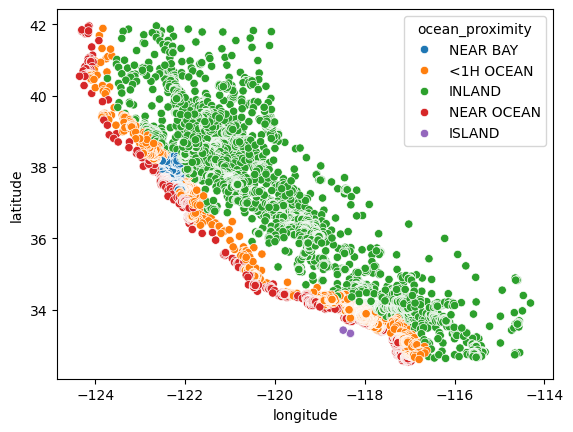

In [40]:
sns.scatterplot(x= 'longitude',y = 'latitude', hue = 'ocean_proximity', data = df)
plt.show()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [42]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [43]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [44]:
df['total_bedrooms'] =  df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [45]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [46]:
#Apply get_dummies to do OneHotEncoding

df = pd.get_dummies(df, drop_first= True, prefix = 'OP', dtype = 'int')

In [47]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,OP_INLAND,OP_ISLAND,OP_NEAR BAY,OP_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [48]:
##Features and Target Split

X = df.drop(columns =  ['median_house_value'])
y = df['median_house_value']

In [49]:
X.shape

(20640, 12)

In [50]:
## Perform train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 25)


## Date: 26-08-2025

In [53]:
## Perform K Fold Validation

## Let us set up the kfold
kf = KFold(n_splits = 10, random_state =25, shuffle = True)


## Initialize the Model

model = LinearRegression()

## Evaluate the model on cross validation sets

k_fold_scores =  cross_val_score(model, X_train,y_train, scoring ='r2', cv = kf)


## Print cross val scores

print(k_fold_scores)
print(f'Average cross Validation r2 Score: {k_fold_scores.mean():.4f}')

[0.64903686 0.65700771 0.57703987 0.64447375 0.65028899 0.65056426
 0.62998423 0.63084079 0.65222269 0.67534486]
Average cross Validation r2 Score: 0.6417


This tells us that the feature are able to explain 64% of variability of the target variable, however 36% of the variation in target variable are still to be explained

In [58]:
## Let train the model on full train data and evaluate on test data

model.fit(X_train, y_train)
y_train_pred =  model.predict(X_train)
y_test_pred =  model.predict(X_test)


print('Performance Metrics'.center(99,'*'))

print(f'MSE Train : {mean_squared_error(y_train, y_train_pred):.4f}')
print(f'MAE Train : {mean_absolute_error(y_train, y_train_pred):.4f}')
print(f'RMSE Train : {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}')
print(f'R2 Train : {r2_score(y_train, y_train_pred):.4f}')

print('-'*50)

print(f'MSE Test : {mean_squared_error(y_test, y_test_pred):.4f}')
print(f'MAE Test : {mean_absolute_error(y_test, y_test_pred):.4f}')
print(f'RMSE Test : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}')
print(f'R2 Test : {r2_score(y_test, y_test_pred):.4f}')

****************************************Performance Metrics****************************************
MSE Train : 4736115155.0570
MAE Train : 49757.1819
RMSE Train : 68819.4388
R2 Train : 0.6439
--------------------------------------------------
MSE Test : 4697911668.2178
MAE Test : 50042.2802
RMSE Test : 68541.3136
R2 Test : 0.6481


Observation:

The Model seems an underfit as there is significantly large Error in median price for both test  and train data which could have been caused due to presence of outliers in the data which is evident as there is a significant difference in the RMSE and MAE values for both train and test data

We can try scaling the data to reduce the size of the error or try methods like woinsorize to handle outlier data before training the model.

## Regularization

**Regularization in Regression**

In linear regression, regularization encompasses a set of techniques employed to address the issue of overfitting.

**Core Concept**

Regularization techniques achieve their objective by introducing a penalty term to the model's objective function. This objective function, typically measured by mean squared error, is minimized during the training process. The penalty term discourages the model from attaining excessive complexity by penalizing the size of the model coefficients, thereby mitigating overfitting.

**Regularization term** or `alpha`: is a hyperparameter that scales the penalty term. It controls the strength of regularization.
- Higher `alpha`: Imposes a stronger penalty on the coefficients, leading to greater regularization. This tends to produce a simpler model that may underfit the training data but often generalizes better to unseen data.


- Lower `alpha`: Imposes a weaker penalty, leading to a model that is less restricted by the regularization and more complex, potentially capturing more details in the data but at the risk of overfitting.

**Benefits of Regularization**

Enhanced Generalizability: By mitigating overfitting, regularization fosters models that perform well on unseen data.

Reduced Model Complexity: It promotes interpretability and potentially reduces computational costs associated with training complex models.


Common Regularization Techniques are:

* Lasso Regression (L1 Regularization)
* Ridge Regression (L2 Regularization)

## LASSO Regression - 
### Least Absolute Shrinkage and Selection Operator

It relies upon the linear regression but additionaly performs so called L1 Regularization, which is a process in which it introduces additional information to curb overfitting.
- It performs variable selection
- it forces some of the coefficients to be exactly zero with the help large `alpha`
- it reduces the learning of more complex model and may address the overfitting issue.
- it decrease the variance of the model without an increase in bias.
  
Mathematically,
 - In Regression the objective function is **Residual Sum of Squares** given as
$$
\text{RSS}  =  \sum_{i=1}^n {(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))}^2
$$
The Lasso regression penalizes the coefficents by the sum of absolute coefficient controlled by `alpha` and modifies the objective function as :


$$
 \sum_{i=1}^n {(y_{i} - (\beta_{0} + \sum_{j=1}^{p} \beta_{j}x_{j}))}^2 + \alpha \sum_{j=1}^{p}|\beta_{j}|
$$
where $\alpha$ can take various values:
- $\alpha = 0$ : Same coefficients as least squares linear regression
- $\alpha = \infty$ : all coefficients are zero
- $0< \alpha < \infty $ : Coefficients are between 0 and that of least squares linear regression

In [59]:
## Let us implement Lasso Model

data info: https://cran.r-project.org/web/packages/ISLR/ISLR.pdf

In [60]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [61]:
df = pd.read_csv('hitters.csv')

In [62]:
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [63]:
#Drop Unnamed: 0 Column


df  = df.drop(columns = ['Unnamed: 0'])

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [71]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [65]:
# Check for missing value

df.isnull().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [70]:
print(f'Missing Data %age in Salary : {df.isnull().sum()['Salary']/df.shape[0]* 100:.4f}')

Missing Data %age in Salary : 18.3230


Since our target variable has 18% missing values, ideally it is not advisable to replace the missing value in the target variable, however as an exception due to small data size (322 samples) dropping that many rows may cause significant loss of data, Hence replace the missing values with appropriate metric

In [78]:
## Fill Missing Values with median as Salary is positively skewed
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy =  'median')
df['Salary'] = si.fit_transform(df[['Salary']]).flatten()

In [79]:
df.isnull().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

In [80]:
print(df['League'].unique())
print(df['Division'].unique())
print(df['NewLeague'].unique())

['A' 'N']
['E' 'W']
['A' 'N']


In [81]:
df = pd.get_dummies(df, drop_first = True, dtype =  'int')

In [82]:
## Seperate Feature and Target and perform train test split

X   = df.drop(columns = ['Salary'])
y =  df['Salary']

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size = 0.2, random_state = 25)

X_train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000
mean,381.813230,101.894942,10.789883,51.428016,48.182879,38.354086,7.474708,2672.595331,727.225681,68.568093,360.918288,331.961089,255.159533,291.587549,100.311284,7.961089,0.431907,0.521401,0.435798
std,158.430967,47.777649,8.714359,26.926471,26.501799,22.067437,5.004719,2360.794579,669.718075,85.226561,337.489417,336.397514,257.396706,286.720644,134.021149,6.455258,0.496308,0.500517,0.496828
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,246.000000,63.000000,4.000000,30.000000,29.000000,22.000000,4.000000,805.000000,209.000000,14.000000,102.000000,88.000000,65.000000,109.000000,6.000000,3.000000,0.000000,0.000000,0.000000
50%,381.000000,100.000000,8.000000,49.000000,45.000000,34.000000,6.000000,1968.000000,543.000000,36.000000,247.000000,230.000000,166.000000,220.000000,33.000000,6.000000,0.000000,1.000000,0.000000
75%,520.000000,138.000000,17.000000,70.000000,65.000000,53.000000,11.000000,3949.000000,1066.000000,90.000000,544.000000,435.000000,337.000000,325.000000,152.000000,11.000000,1.000000,1.000000,1.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,1.000000,1.000000,1.000000


<Axes: ylabel='Density'>

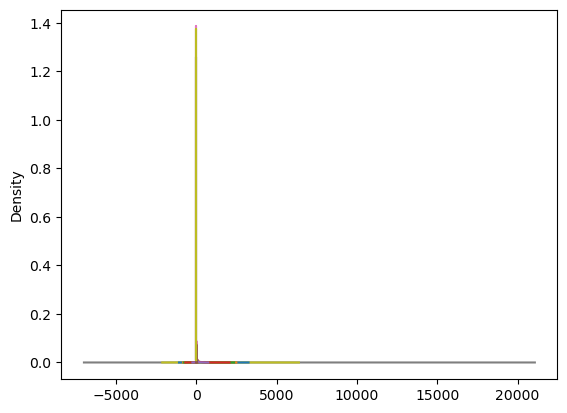

In [85]:
X_train.plot.kde(legend= False)

Data Appears to Near Normal Distributed with some Outliers. It is also evident from kdeplot that the data is not in standardized form Hence standardize the data

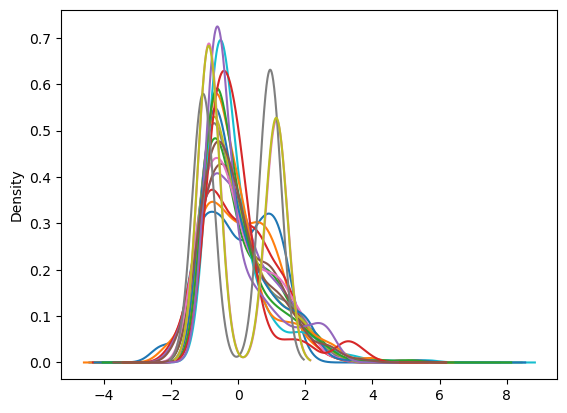

In [86]:
xtr_copy =  X_train.copy()
xte_copy =  X_test.copy()

#numpy method

X_mean =  xtr_copy.mean()
X_std =  xtr_copy.std()
xtr_copy =  (xtr_copy - X_mean)/X_std
xte_copy =  (xte_copy - X_mean)/X_std

pd.DataFrame(xtr_copy, columns =  xtr_copy.columns).plot.kde(legend=False)
plt.show()

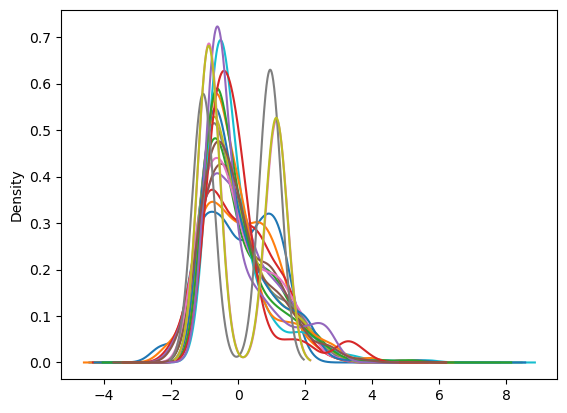

In [88]:
## using sklearn
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled =  sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

pd.DataFrame(X_train_scaled, columns =  X_train.columns).plot.kde(legend=False)
plt.show()

In [89]:
lr =  LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [90]:
coef_df =  pd.DataFrame(lr.coef_, index = X_train.columns, columns = ['COEF- Linear Regression'])
coef_df 
                        

,COEF- Linear Regression
AtBat,-270.329315
Hits,184.233976
HmRun,10.624640
Runs,50.352431
RBI,43.984221
Walks,79.622627
Years,-48.719154
CAtBat,-332.404426
CHits,239.566774
CHmRun,-42.707451


In [99]:
## With Lasso Model

lasso = Lasso(alpha = 1)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=1)

In [100]:
coef_df['COEF- Lasso'] =  lasso.coef_
coef_df

,COEF- Linear Regression,COEF- Lasso
AtBat,-270.329315,-279.697433
Hits,184.233976,203.790171
HmRun,10.624640,0.000000
Runs,50.352431,47.452321
RBI,43.984221,52.724462
Walks,79.622627,73.854245
Years,-48.719154,-68.182373
CAtBat,-332.404426,-29.623600
CHits,239.566774,48.199295
CHmRun,-42.707451,-0.000000
